In [1]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [2]:
x_train=x_train/255.0
x_test=x_test/255.0

In [3]:
x_train=x_train.reshape(-1,28,28,1)

In [4]:
model=models.Sequential()

In [5]:
model.add(layers.Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)))

D:\ANN_LABS\env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.add(layers.MaxPooling2D((2,2)))

In [7]:
model.add(layers.Flatten())

In [8]:
model.add(layers.Dense(64,activation="relu"))

In [9]:
model.add(layers.Dense(10,activation="softmax"))

In [10]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",
             metrics=['accuracy'])

In [11]:
model.fit(x_train,y_train,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9522 - loss: 0.1663
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9824 - loss: 0.0584
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9881 - loss: 0.0394


In [12]:
loss,accuracy=model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9848 - loss: 0.0450


In [19]:
prediction = model.predict(x_test)
print(prediction[0])
for i in range(10):
    predicted = np.argmax(prediction[i])
    actual = y_test[i]

    print(f"Image {i}")
    print("Predicted:", predicted)
    print("Actual:", actual)
    print()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[7.5791722e-06 2.4078417e-06 6.9409616e-05 3.6835394e-04 1.1039410e-08
 2.3333183e-07 7.1298792e-12 9.9953675e-01 1.5297686e-06 1.3842448e-05]
Image 0
Predicted: 7
Actual: 7

Image 1
Predicted: 2
Actual: 2

Image 2
Predicted: 1
Actual: 1

Image 3
Predicted: 0
Actual: 0

Image 4
Predicted: 4
Actual: 4

Image 5
Predicted: 1
Actual: 1

Image 6
Predicted: 4
Actual: 4

Image 7
Predicted: 9
Actual: 9

Image 8
Predicted: 5
Actual: 5

Image 9
Predicted: 9
Actual: 9



In [14]:
print(np.argmax(prediction[0]))


7


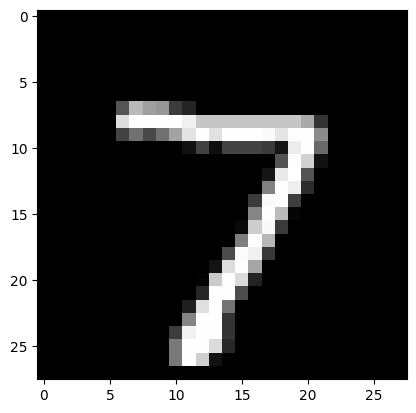

In [15]:
plt.imshow(x_test[0].reshape(28,28),cmap="gray")